In [50]:
#Extraccion y tratamiento de datos
import pandas as pd
import numpy as np
#Visualizacion de datos
import seaborn as sb
import matplotlib.pyplot as plt
import plotly.express as px
#Analisis estadistico
import empiricaldist
import scipy
import statsmodels.api as sm
import inspect
#Advertencias
import warnings
warnings.filterwarnings('ignore')

# Obtener la fuente de datos Penguins

In [2]:
data = pd.read_csv('https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv')
data.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [3]:
# Cantidad de nulos, tipos de datos y cantidad de variables
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 21.6 KB


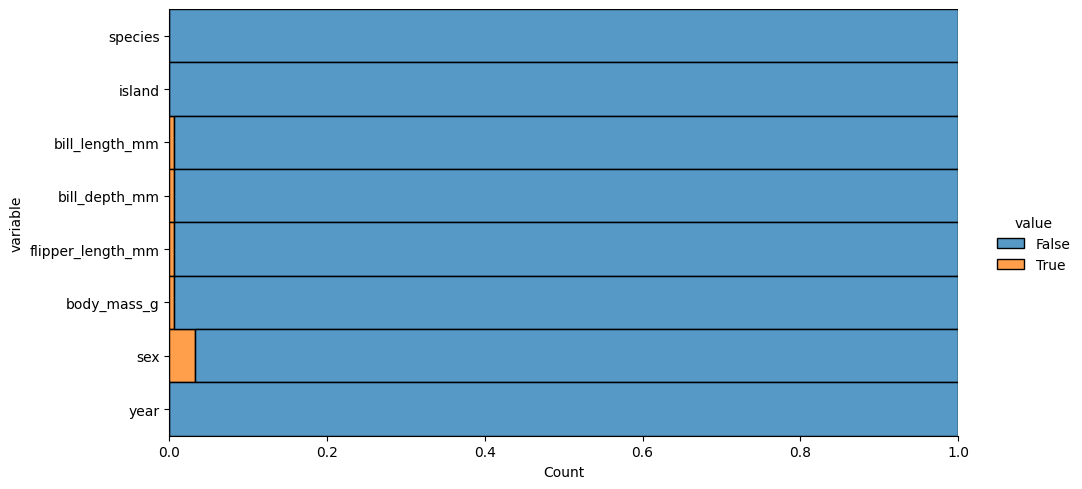

In [4]:
#Grafico de proporcion de nulidad
data.isnull().melt().pipe(lambda df: (sb.displot(data= df, y='variable', hue='value', multiple='fill', aspect=2)))

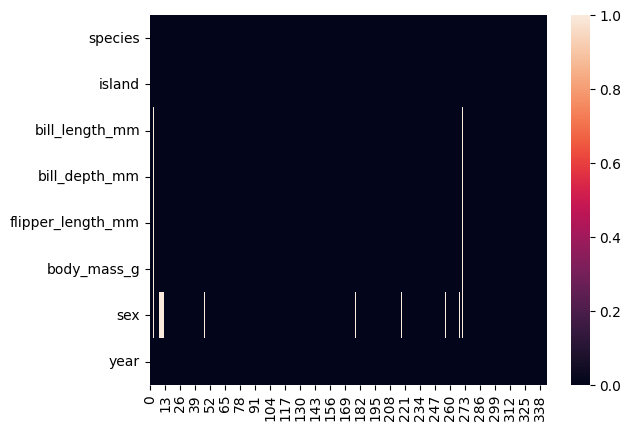

In [5]:
# Grafico de dispersion de nulos
data.isnull().transpose().pipe(lambda df: (sb.heatmap(data= df)));

In [6]:
data_mod = data.dropna()
data_mod.info()

<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    str    
 1   island             333 non-null    str    
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    str    
 7   year               333 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 23.4 KB


# Estadisticos univariados

In [ ]:
data_mod.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
species,333,3,Adelie,146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
island,333,3,Biscoe,163,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bill_length_mm,333.0,NaN,NaN,NaN,43.992793,5.468668,32.1,39.5,44.5,48.6,59.6
bill_depth_mm,333.0,NaN,NaN,NaN,17.164865,1.969235,13.1,15.6,17.3,18.7,21.5
flipper_length_mm,333.0,NaN,NaN,NaN,200.966967,14.015765,172.0,190.0,197.0,213.0,231.0
body_mass_g,333.0,NaN,NaN,NaN,4207.057057,805.215802,2700.0,3550.0,4050.0,4775.0,6300.0
sex,333,2,male,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,333.0,NaN,NaN,NaN,2008.042042,0.812944,2007.0,2007.0,2008.0,2009.0,2009.0


In [8]:
# Numericas
data_mod.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
bill_length_mm,333.0,43.992793,5.468668,32.1,39.5,44.5,48.6,59.6
bill_depth_mm,333.0,17.164865,1.969235,13.1,15.6,17.3,18.7,21.5
flipper_length_mm,333.0,200.966967,14.015765,172.0,190.0,197.0,213.0,231.0
body_mass_g,333.0,4207.057057,805.215802,2700.0,3550.0,4050.0,4775.0,6300.0
year,333.0,2008.042042,0.812944,2007.0,2007.0,2008.0,2009.0,2009.0


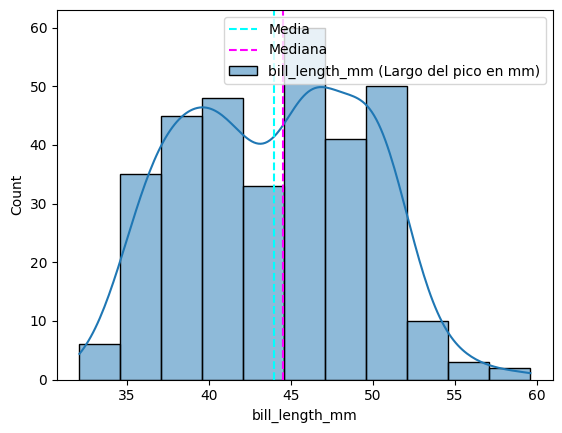

In [9]:
#bill_length_mm
sb.histplot(data= data_mod, x='bill_length_mm', kde=True, label='bill_length_mm (Largo del pico en mm)')
plt.axvline(x = data_mod.bill_length_mm.mean(), color = 'cyan', linestyle = 'dashed', label = 'Media')
plt.axvline(x = data_mod.bill_length_mm.median(), color = 'magenta', linestyle = 'dashed', label = 'Mediana')
plt.legend()
plt.show()

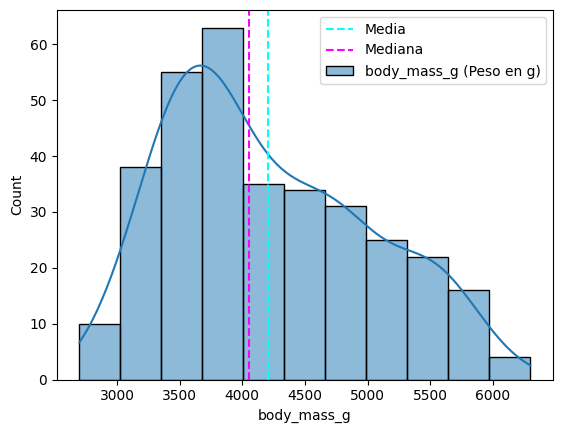

In [10]:
#body_mass_g
sb.histplot(data= data_mod, x='body_mass_g', kde=True, label='body_mass_g (Peso en g)')
plt.axvline(x = data_mod.body_mass_g.mean(), color = 'cyan', linestyle = 'dashed', label = 'Media')
plt.axvline(x = data_mod.body_mass_g.median(), color = 'magenta', linestyle = 'dashed', label = 'Mediana')
plt.legend()
plt.show()

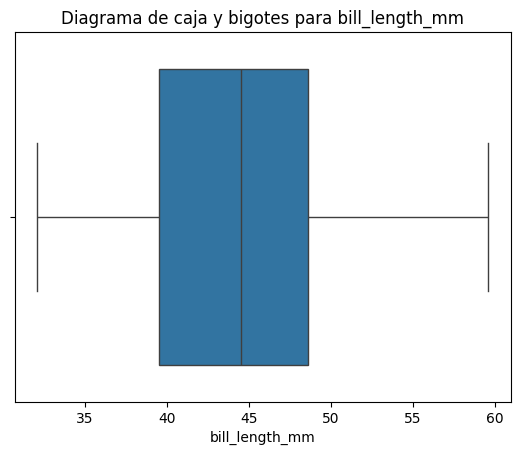

In [11]:
#Diagrama de caja y bigotes para bill_length_mm
sb.boxplot(data= data_mod, x='bill_length_mm')
plt.title('Diagrama de caja y bigotes para bill_length_mm')
plt.show()

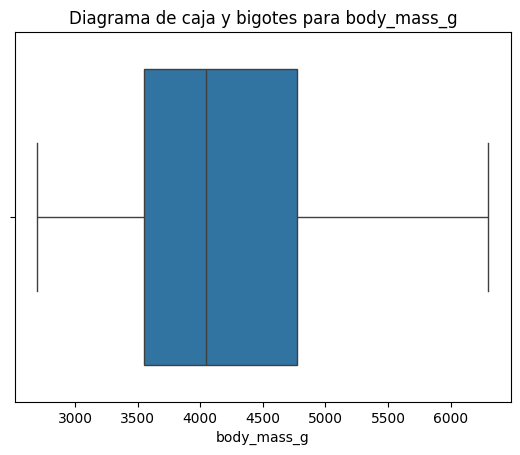

In [12]:
# Diagrama de caja y bigotes para body_mass_g
sb.boxplot(data= data_mod, x='body_mass_g')
plt.title('Diagrama de caja y bigotes para body_mass_g')
plt.show()

In [13]:
# Categoricas 
data_mod.describe(include='object').transpose()

,count,unique,top,freq
species,333,3,Adelie,146
island,333,3,Biscoe,163
sex,333,2,male,168


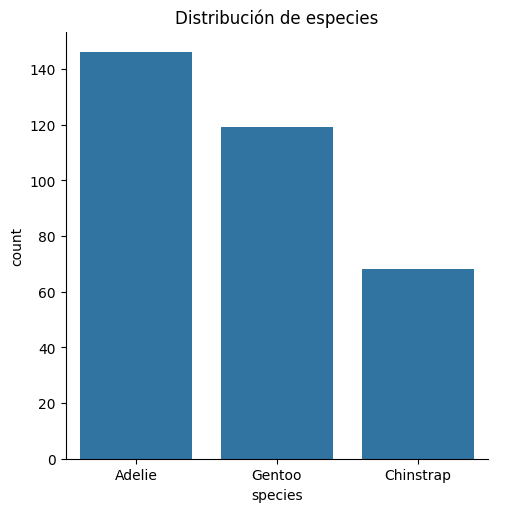

In [14]:
# Grafico de categorias
sb.catplot(data= data_mod, x='species', kind='count')
plt.title('Distribución de especies')
plt.show()

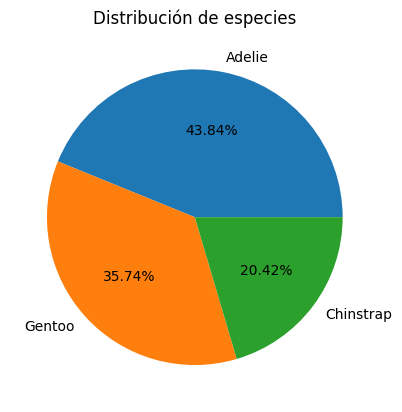

In [15]:
# Grafico de torta
plt.pie(x=data_mod.species.value_counts(), labels=data_mod.species.value_counts().index, autopct='%.2f%%')
plt.title('Distribución de especies')
plt.show()

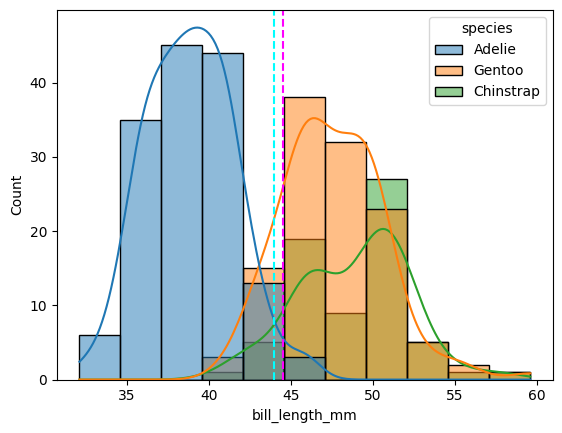

In [16]:
# Estadisticos bivariados
## Histograma de frecuencias estratificado por una clase
#bill_length_mm vs species
sb.histplot(data= data_mod, x='bill_length_mm', kde=True ,hue='species')
plt.axvline(x = data_mod.bill_length_mm.mean(), color = 'cyan', linestyle = 'dashed', label = 'Media')
plt.axvline(x = data_mod.bill_length_mm.median(), color = 'magenta', linestyle = 'dashed', label = 'Mediana')
plt.show()

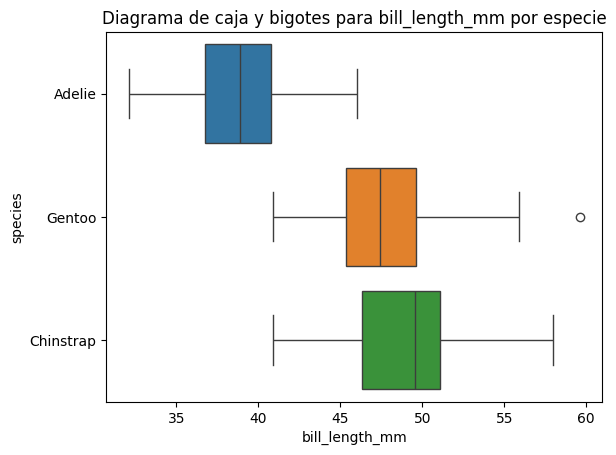

In [17]:
#Diagrama de caja y bigotes para bill_length_mm
sb.boxplot(data= data_mod, x='bill_length_mm', y='species', hue='species')
plt.title('Diagrama de caja y bigotes para bill_length_mm por especie')
plt.show()

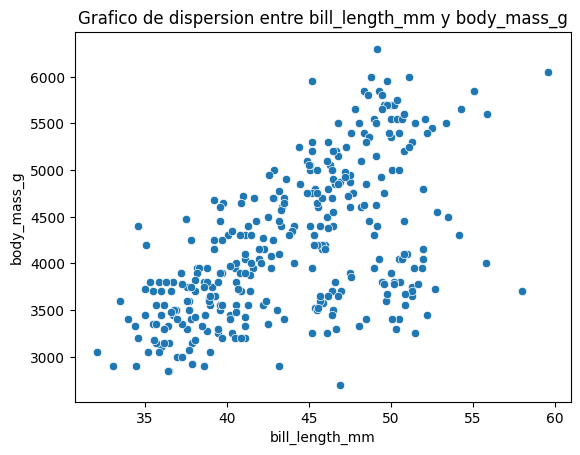

In [18]:
# Grafico de dispersion
sb.scatterplot(data= data_mod, x='bill_length_mm', y='body_mass_g')
plt.title('Grafico de dispersion entre bill_length_mm y body_mass_g')
plt.show()

In [19]:
# Grafico de dispersion dinamico (este serua multivariado)
px.scatter(data_mod, x='bill_length_mm', y='bill_depth_mm', color='species', title='Grafico de dispersion entre bill_length_mm y bill_depth_mm por especie')

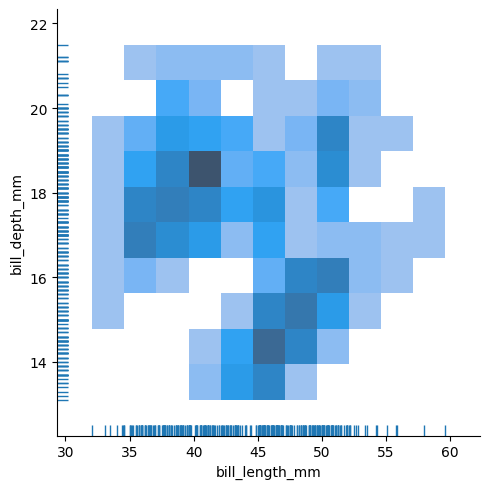

In [20]:
# Grafico de dispersion por densidad
sb.displot(data= data_mod, x='bill_length_mm', y='bill_depth_mm', rug=True)

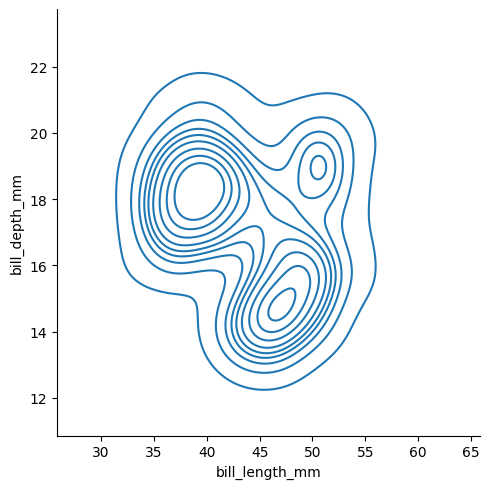

In [21]:
# Grafico de dispersion por curvas de densidad
sb.displot(data= data_mod, x='bill_length_mm', y='bill_depth_mm', kind='kde')

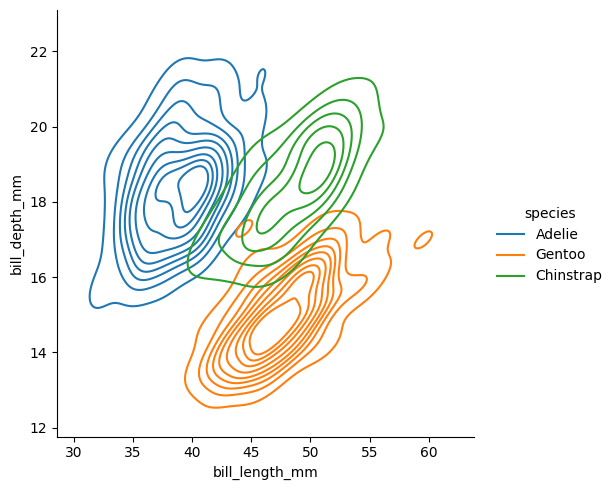

In [22]:
# Grafico de dispersion por curvas de densidad estratificado por especie
sb.displot(data= data_mod, x='bill_length_mm', y='bill_depth_mm', kind='kde', hue='species')

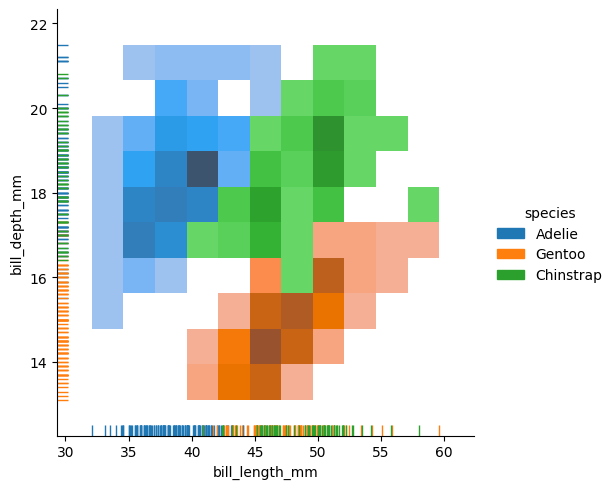

In [23]:
# Grafico de dispersion por densidad por especie
sb.displot(data= data_mod, x='bill_length_mm', y='bill_depth_mm', rug=True, hue='species')

In [24]:
# Grafico dinamico multiple
px.scatter_3d(data_mod, x='bill_length_mm', y='flipper_length_mm', z='body_mass_g', title='Grafico de dispersion entre bill_length_mm, flipper_length_mm y body_mass_g ')

In [25]:
# Grafico dinamico multiple
px.scatter_3d(data_mod, x='bill_length_mm', y='flipper_length_mm', z='body_mass_g', size='bill_depth_mm', title='Grafico de dispersion entre bill_length_mm, flipper_length_mm y body_mass_g con tamaño de bill_depth_mm ')

In [26]:
# Grafico dinamico multiple
px.scatter_3d(data_mod, x='bill_length_mm', y='flipper_length_mm', z='body_mass_g', size='bill_depth_mm', color='species', title='Grafico de dispersion entre bill_length_mm, flipper_length_mm y body_mass_g con tamaño de bill_depth_mm y color por especie ')

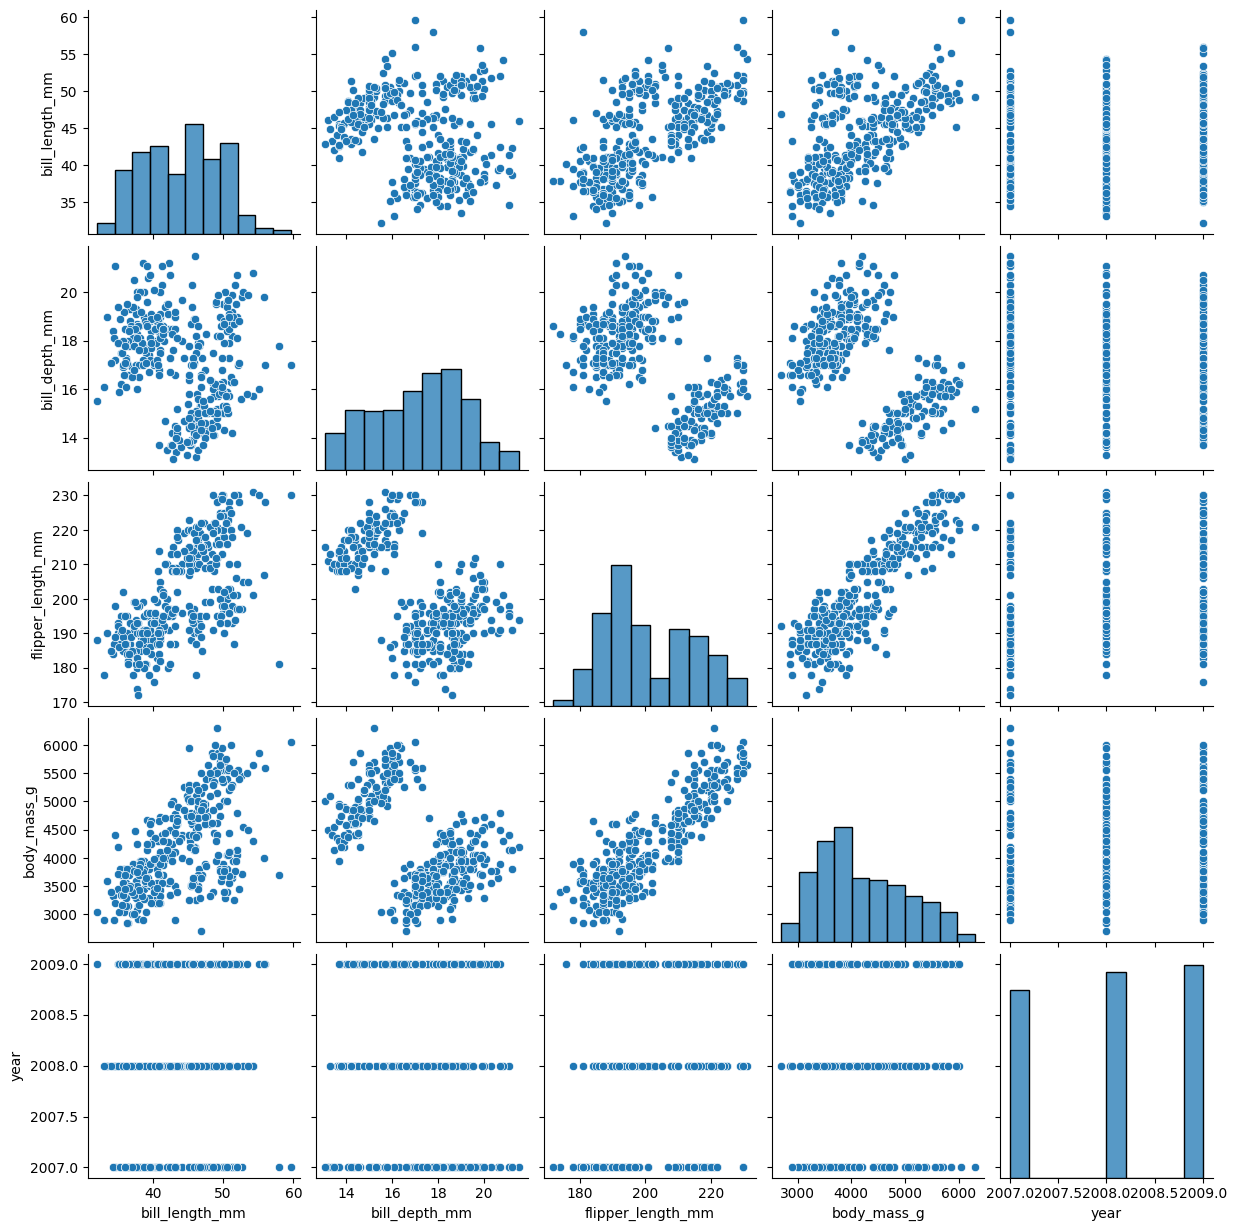

In [28]:
sb.pairplot(data=data_mod)

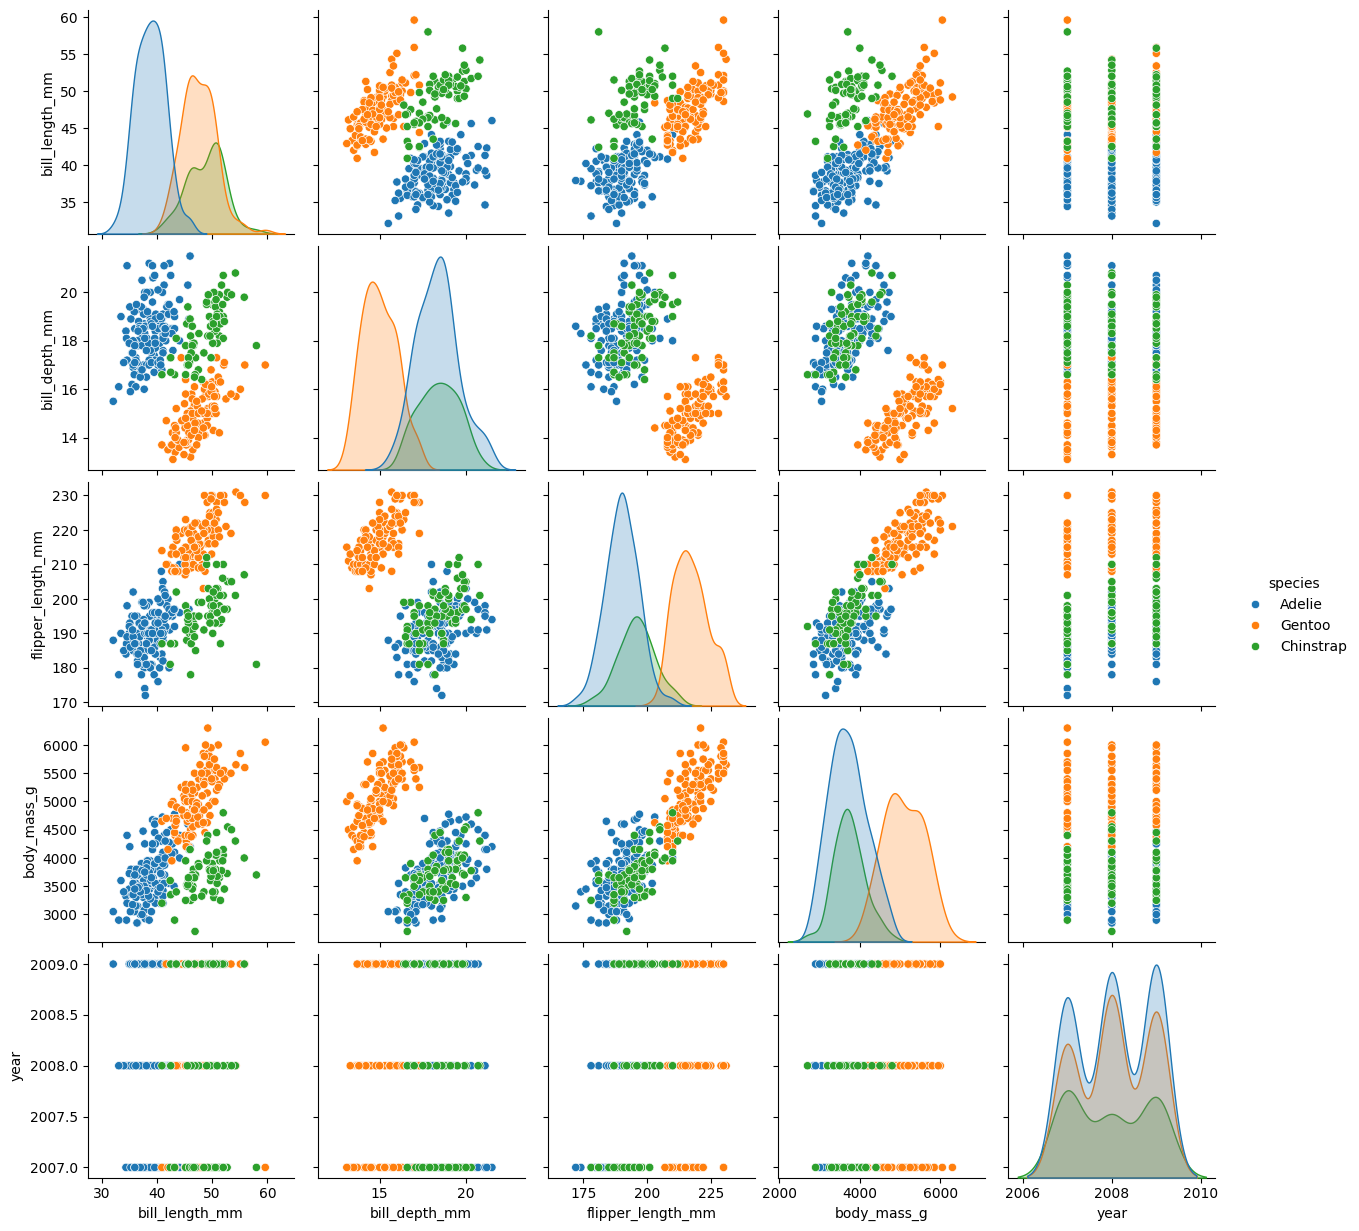

In [29]:
sb.pairplot(data=data_mod, hue='species')

# Relaciones

## Covarianza

In [30]:
data_mod.cov(numeric_only=True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
bill_length_mm,29.906333,-2.462091,50.058195,2595.623304,0.145183
bill_depth_mm,-2.462091,3.877888,-15.947248,-748.456122,-0.077133
flipper_length_mm,50.058195,-15.947248,196.441677,9852.191649,1.721272
body_mass_g,2595.623304,-748.456122,9852.191649,648372.487699,14.310847
year,0.145183,-0.077133,1.721272,14.310847,0.660878


<Axes: >

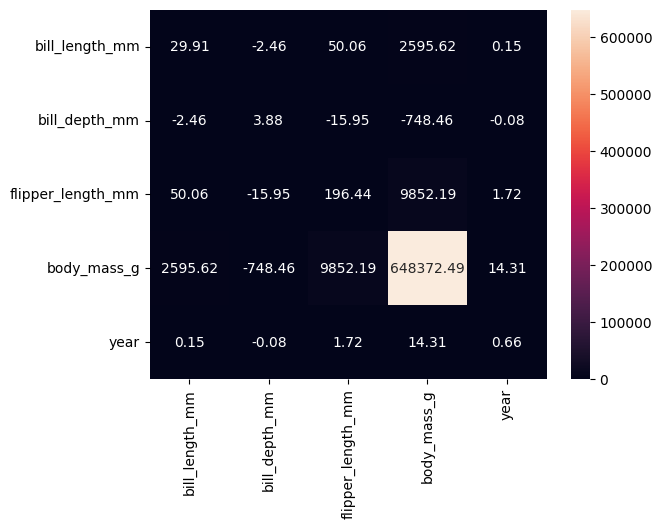

In [31]:
sb.heatmap(data=data_mod.cov(numeric_only=True), annot=True, fmt='0.2f')

## Correlacion

In [32]:
data_mod.corr(numeric_only=True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
bill_length_mm,1.000000,-0.228626,0.653096,0.589451,0.032657
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016,-0.048182
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979,0.151068
body_mass_g,0.589451,-0.472016,0.872979,1.000000,0.021862
year,0.032657,-0.048182,0.151068,0.021862,1.000000


<Axes: >

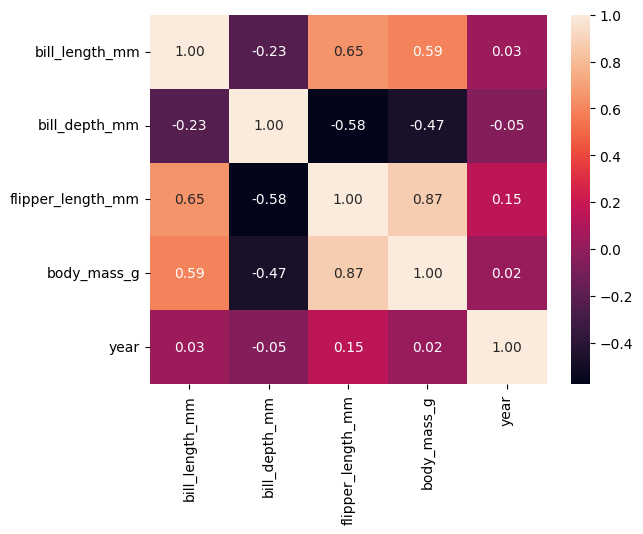

In [33]:
sb.heatmap(data_mod.corr(numeric_only=True), annot=True, fmt='0.2f')

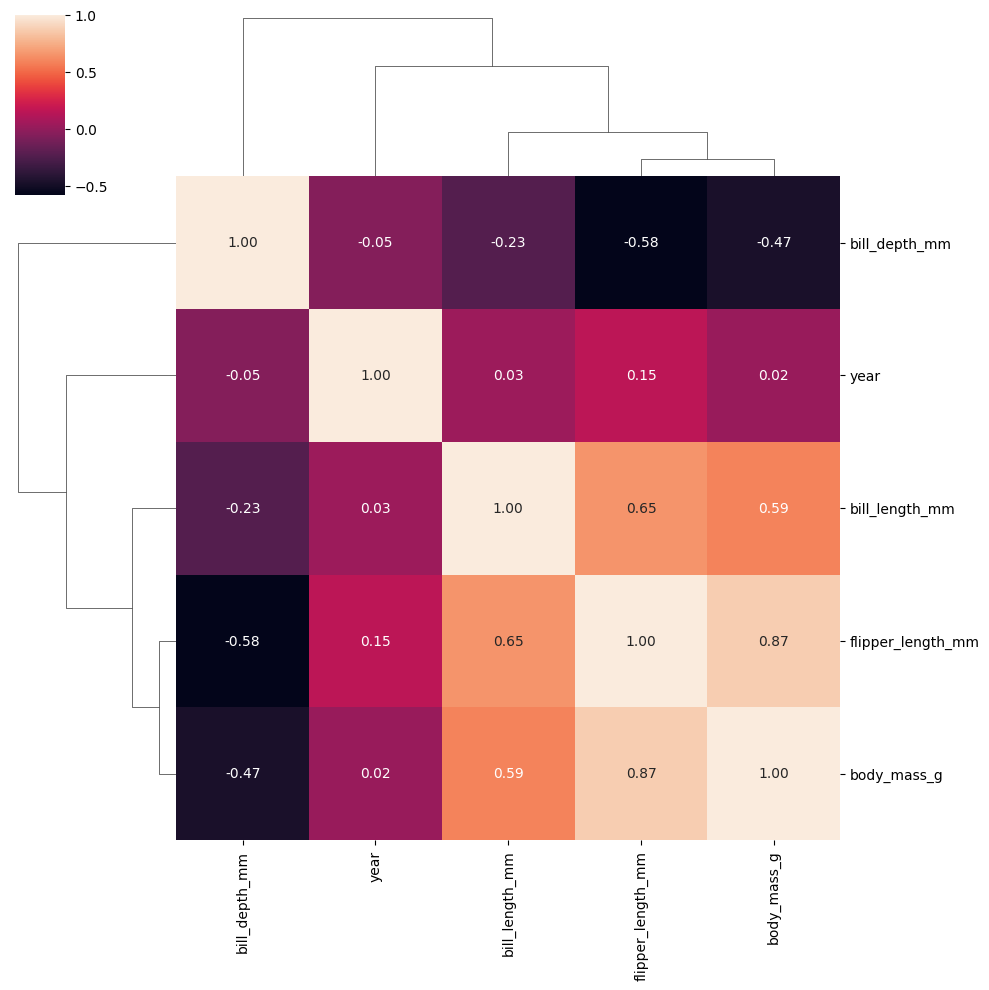

In [ ]:
sb.clustermap(data=data_mod.corr(numeric_only=True), annot=True, fmt='0.2f')

### Correlacíon con variables categoricas

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline

#### OrdinalEncoder

In [38]:
num_cols = data_mod.select_dtypes(include='number').columns.to_list()
cat_cols = data_mod.select_dtypes(include='object').columns.to_list()

num_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

cat_transformer = Pipeline(steps=[
    ('encoder', OrdinalEncoder())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
], remainder='passthrough')

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

In [39]:
data_pre = preprocessor.fit_transform(data_mod)
data_pro = pd.DataFrame(data_pre, columns=num_cols + cat_cols)
data_pro.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year,species,island,sex
0,0.254545,0.666667,0.152542,0.291667,0.0,0.0,2.0,1.0
1,0.269091,0.511905,0.237288,0.305556,0.0,0.0,2.0,0.0
2,0.298182,0.583333,0.389831,0.152778,0.0,0.0,2.0,0.0
3,0.167273,0.738095,0.355932,0.208333,0.0,0.0,2.0,0.0
4,0.261818,0.892857,0.305085,0.263889,0.0,0.0,2.0,1.0


<Axes: >

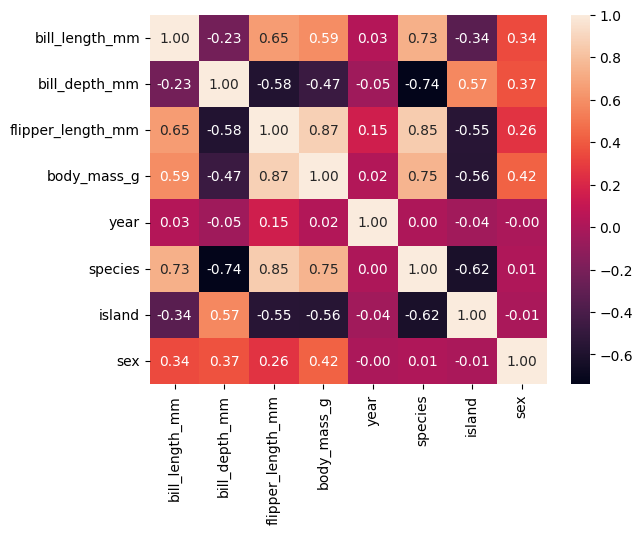

In [40]:
sb.heatmap(data=data_pro.corr(numeric_only=True), annot=True, fmt='0.2f')

#### OneHotEncoder

In [43]:
num_cols = data_mod.select_dtypes(include='number').columns.to_list()
cat_cols = data_mod.select_dtypes(include='object').columns.to_list()

num_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

cat_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
], remainder='passthrough')

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

In [45]:
data_pre = preprocessor.fit_transform(data_mod)
cod_cat = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_cols)

data_pro = pd.DataFrame(data_pre, columns=np.concatenate([num_cols, cod_cat]))
data_pro.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year,species_Adelie,species_Chinstrap,species_Gentoo,island_Biscoe,island_Dream,island_Torgersen,sex_female,sex_male
0,0.254545,0.666667,0.152542,0.291667,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,0.269091,0.511905,0.237288,0.305556,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0.298182,0.583333,0.389831,0.152778,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,0.167273,0.738095,0.355932,0.208333,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,0.261818,0.892857,0.305085,0.263889,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


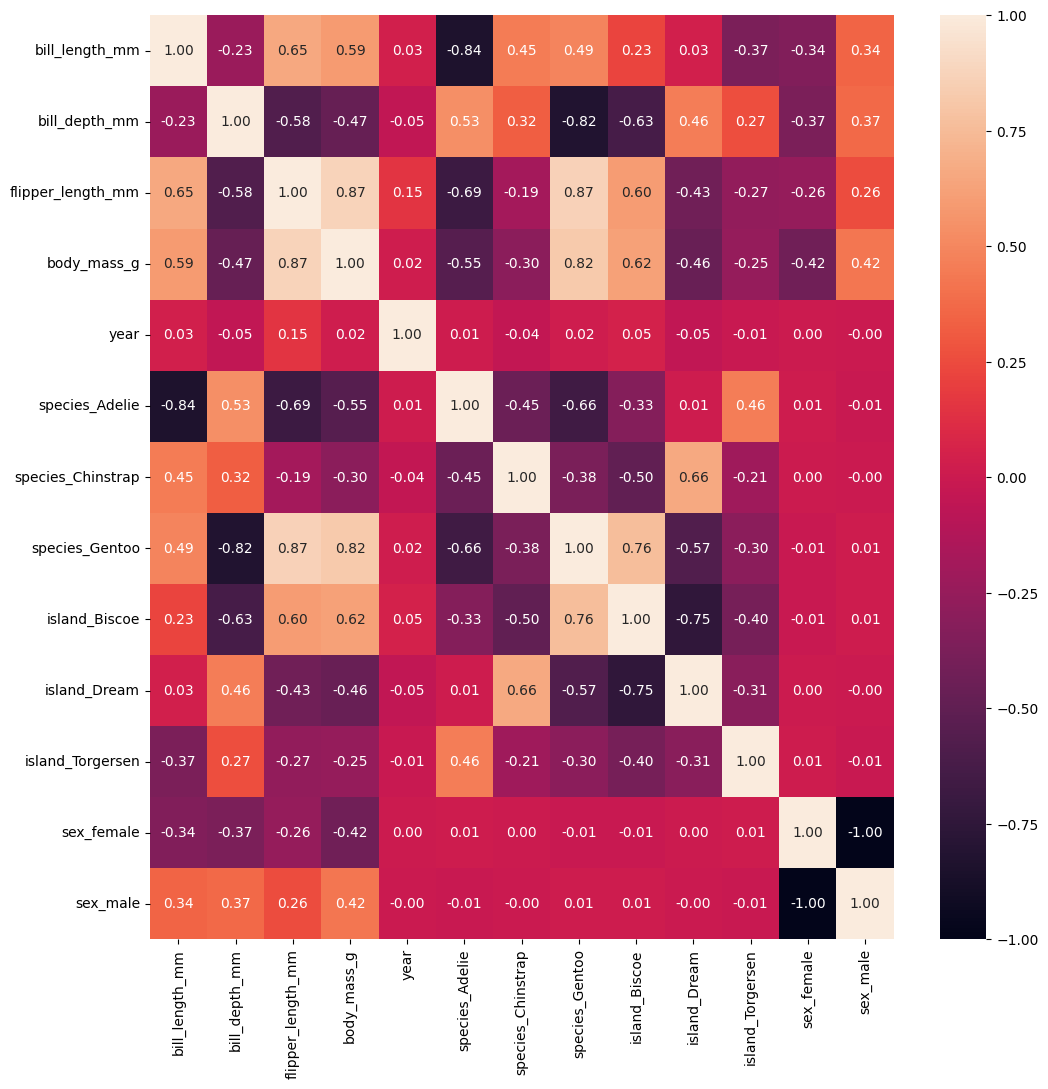

In [47]:
plt.figure(figsize=(12, 12))
sb.heatmap(data=data_pro.corr(numeric_only=True), annot=True, fmt='0.2f')
plt.show()

# Funcion de probabilidad

## 1. Definir el tipo de distribucion a identificar

In [48]:
dist = scipy.stats.norm

## 2. Estimar los parámetros de la FDP

In [ ]:
param = dist.fit(data_mod.bill_length_mm)

## 3. Almacenar los parámetros de función en un diccionario

In [62]:
norm_params = [p for p in inspect.signature(dist._pdf).parameters if not p == 'x'] + ['loc', 'scale']

param_dict = dict(zip(norm_params, param))

## 4. Calcular la Verosimilitud

In [52]:
log_ver = dist.logpdf(data_mod.bill_length_mm, *param).sum()

## 5. Calcular AIC y BIC

In [55]:
aic = -2 * log_ver + 2 * len(param)
bic = -2 * log_ver + np.log(len(data_mod.bill_length_mm)) * len(param)

## 6. Graficar la función de Densidad de Probabilidad

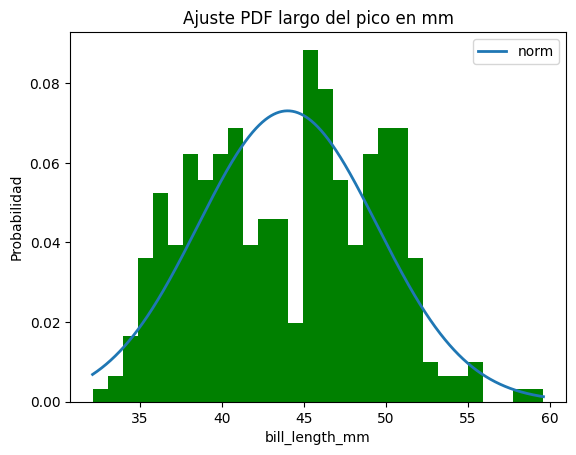

In [56]:
x_hat = np.linspace(np.min(data_mod.bill_length_mm), np.max(data_mod.bill_length_mm), 1000)
y_hat = dist.pdf(x_hat, *param)

fig, ax = plt.subplots()
ax.hist(x = data_mod.bill_length_mm, bins=30, density=True, color='green')
ax.plot(x_hat, y_hat, linewidth=2, label = dist.name)
ax.set_title('Ajuste PDF largo del pico en mm')
ax.set_xlabel('bill_length_mm')
ax.set_ylabel('Probabilidad')
ax.legend()
plt.show()

## Presentar información del ajuste

In [ ]:
print("=" * 50)
print("Resultado del ajuste")
print("=" * 50)

print(f"Distribución: {dist.name}")
print(f"Dominio: {[dist.a, dist.b]}")
print(f"Parámetros: {param_dict}")
print(f"Verosimilitud: {log_ver}")
print(f"AIC: {aic}")
print(f"BIC: {bic}")

Resultado del ajuste
Distribución: norm
Dominio: [-inf, inf]
Parámetros: {'loc': np.float64(43.9927927927928), 'scale': np.float64(5.460450955071463)}
Verosimilitud: -1037.7844807142633
AIC: 2079.5689614285266
BIC: 2087.1852464084873


## Funcion reutilizable Funcion de Probabilidad

In [65]:
def funcion_probabilidad(dist, param):
  norm_params = [p for p in inspect.signature(dist._pdf).parameters if not p == 'x'] + ['loc', 'scale']

  param_dict = dict(zip(norm_params, param))

  log_ver = dist.logpdf(data_mod.bill_length_mm, *param).sum()

  aic = -2 * log_ver + 2 * len(param)
  bic = -2 * log_ver + np.log(len(data_mod.bill_length_mm)) * len(param)

  x_hat = np.linspace(np.min(data_mod.bill_length_mm), np.max(data_mod.bill_length_mm), 1000)
  y_hat = dist.pdf(x_hat, *param)

  fig, ax = plt.subplots()
  ax.hist(x = data_mod.bill_length_mm, bins=30, density=True, color='green')
  ax.plot(x_hat, y_hat, linewidth=2, label = dist.name)
  ax.set_title('Ajuste PDF largo del pico en mm')
  ax.set_xlabel('bill_length_mm')
  ax.set_ylabel('Probabilidad')
  ax.legend()
  plt.show()

  print("=" * 50)
  print("Resultado del ajuste")
  print("=" * 50)

  print(f"Distribución: {dist.name}")
  print(f"Dominio: {[dist.a, dist.b]}")
  print(f"Parámetros: {param_dict}")
  print(f"Verosimilitud: {log_ver}")
  print(f"AIC: {aic}")
  print(f"BIC: {bic}")

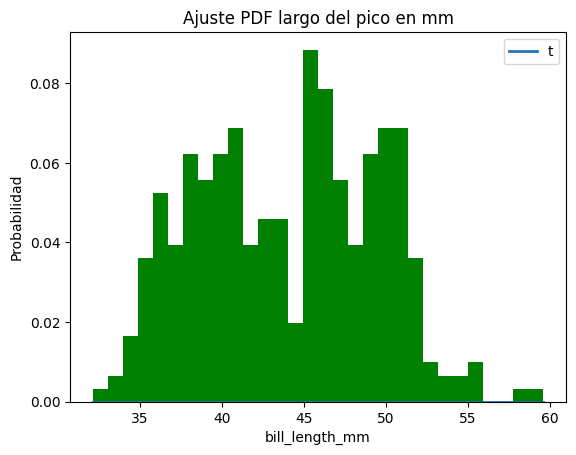

Resultado del ajuste
Distribución: t
Dominio: [-inf, inf]
Parámetros: {'df': np.float64(43.9927927927928), 'loc': np.float64(5.460450955071463)}
Verosimilitud: -26748.8135183193
AIC: 53501.6270366386
BIC: 53509.24332161856


In [66]:
funcion_probabilidad(scipy.stats.t, dist.fit(data_mod.bill_length_mm))